In [1]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('/content/train (1).csv')


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex. Parch

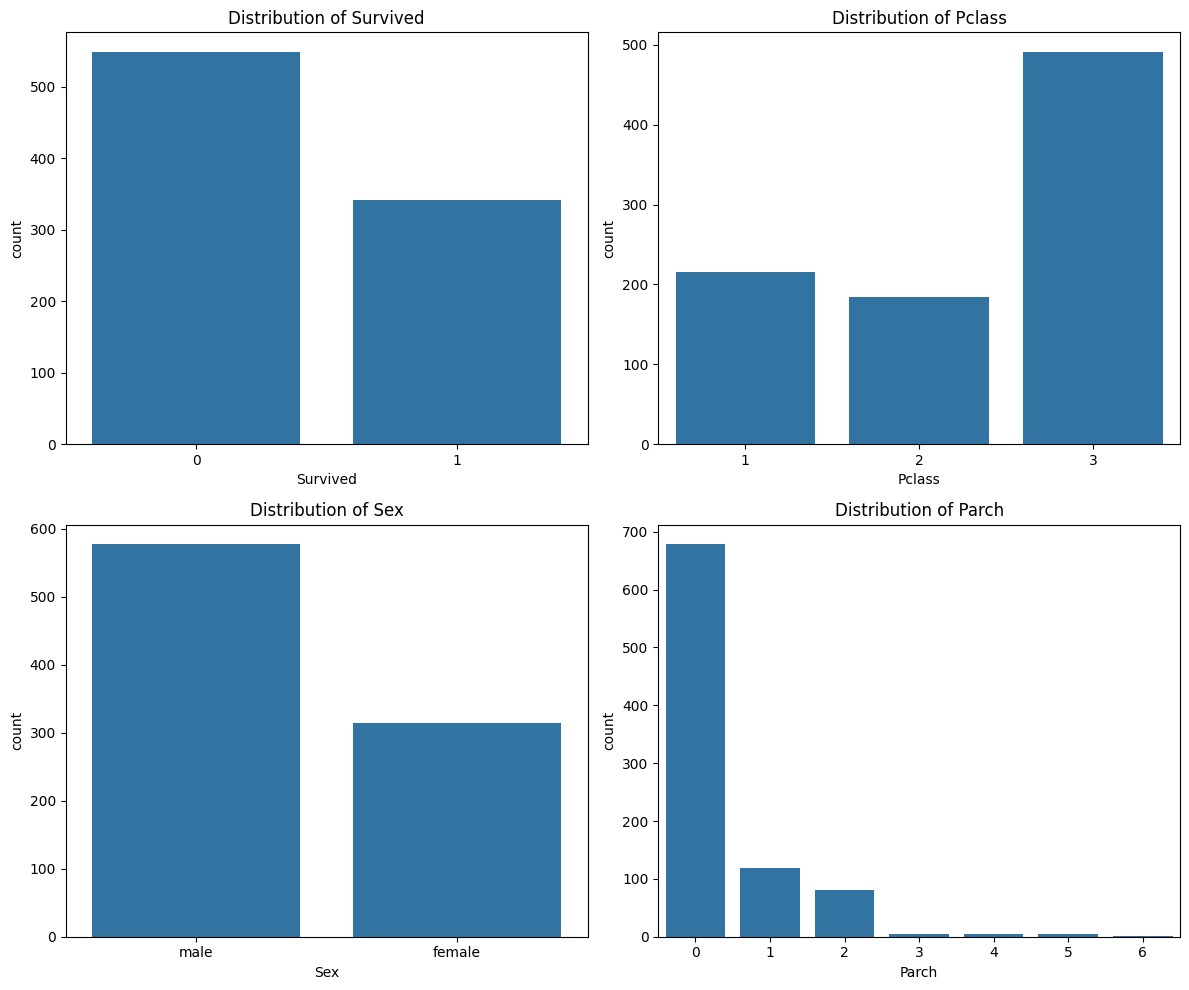

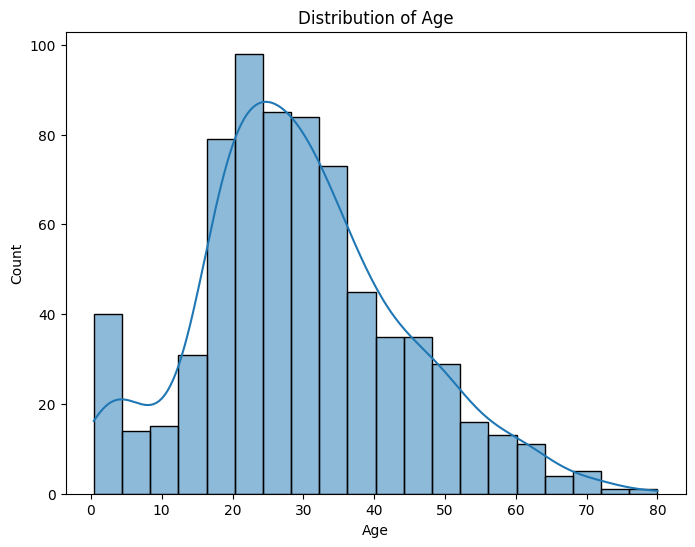

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of Survived
sns.countplot(x='Survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Survived')

# Distribution of Pclass
sns.countplot(x='Pclass', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Pclass')

# Distribution of Sex
sns.countplot(x='Sex', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Sex')

# Distribution of Parch
sns.countplot(x='Parch', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Parch')

plt.tight_layout()
plt.show()

# Distribution of Age
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribution of Age')
plt.show()

Постройте график типа boxplot для столбца Age

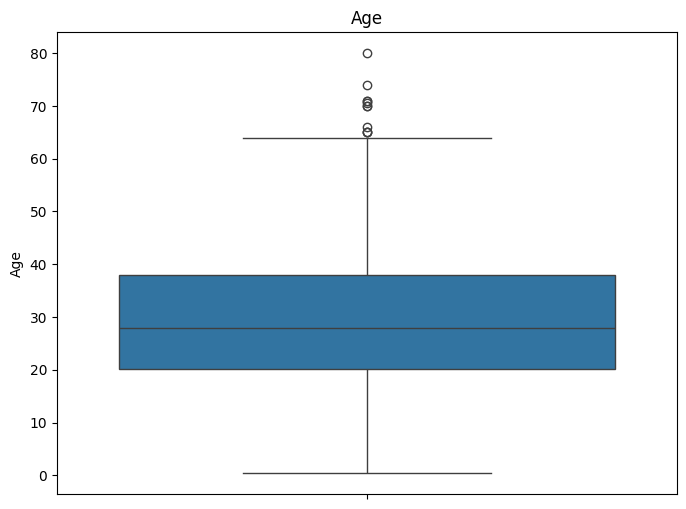

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Age')
plt.title('Age')
plt.show()

In [13]:
median_age = df['Age'].median()
q1_age = df['Age'].quantile(0.25)
q3_age = df['Age'].quantile(0.75)

print(f"Median: {median_age}")
print(f"First Quartile: {q1_age}")
print(f"Third Quartile: {q3_age}")

Median: 28.0
First Quartile: 20.125
Third Quartile: 38.0


Проинтепретируйте полученный график:

1. медиана возраста 28 лет (линия внутри прямоугольника)
2. Первый квартиль (нижняя граница прямоугольника) -- отделяет 25% наименьших значений в наборе данных = 20.125
3. Третий квартиль (верхняя граница прямоугольника) -- отделяет 25% наибольших значений в наборе данных = 38
4. "Усы" показывают разброс данных
5. кружочки выше "верхнего уса" показывают выбросы

Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах

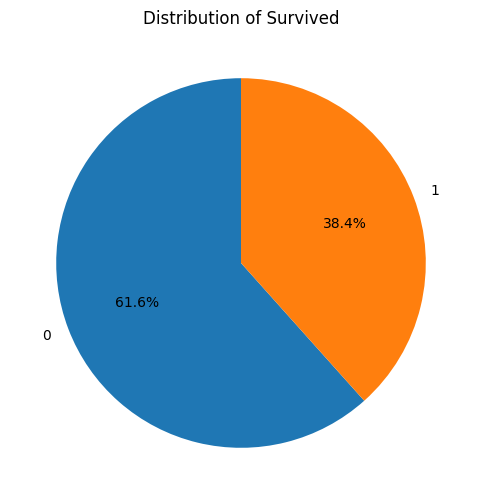

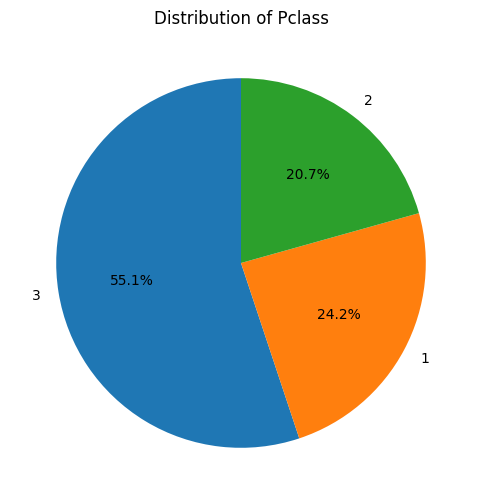

In [14]:
# Pie chart for Survived
survived_counts = df['Survived'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(survived_counts, labels=survived_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Survived')
plt.show()

# Pie chart for Pclass
pclass_counts = df['Pclass'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(pclass_counts, labels=pclass_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Pclass')
plt.show()

Постройте график типа pairplot для всех числовых переменных датасета

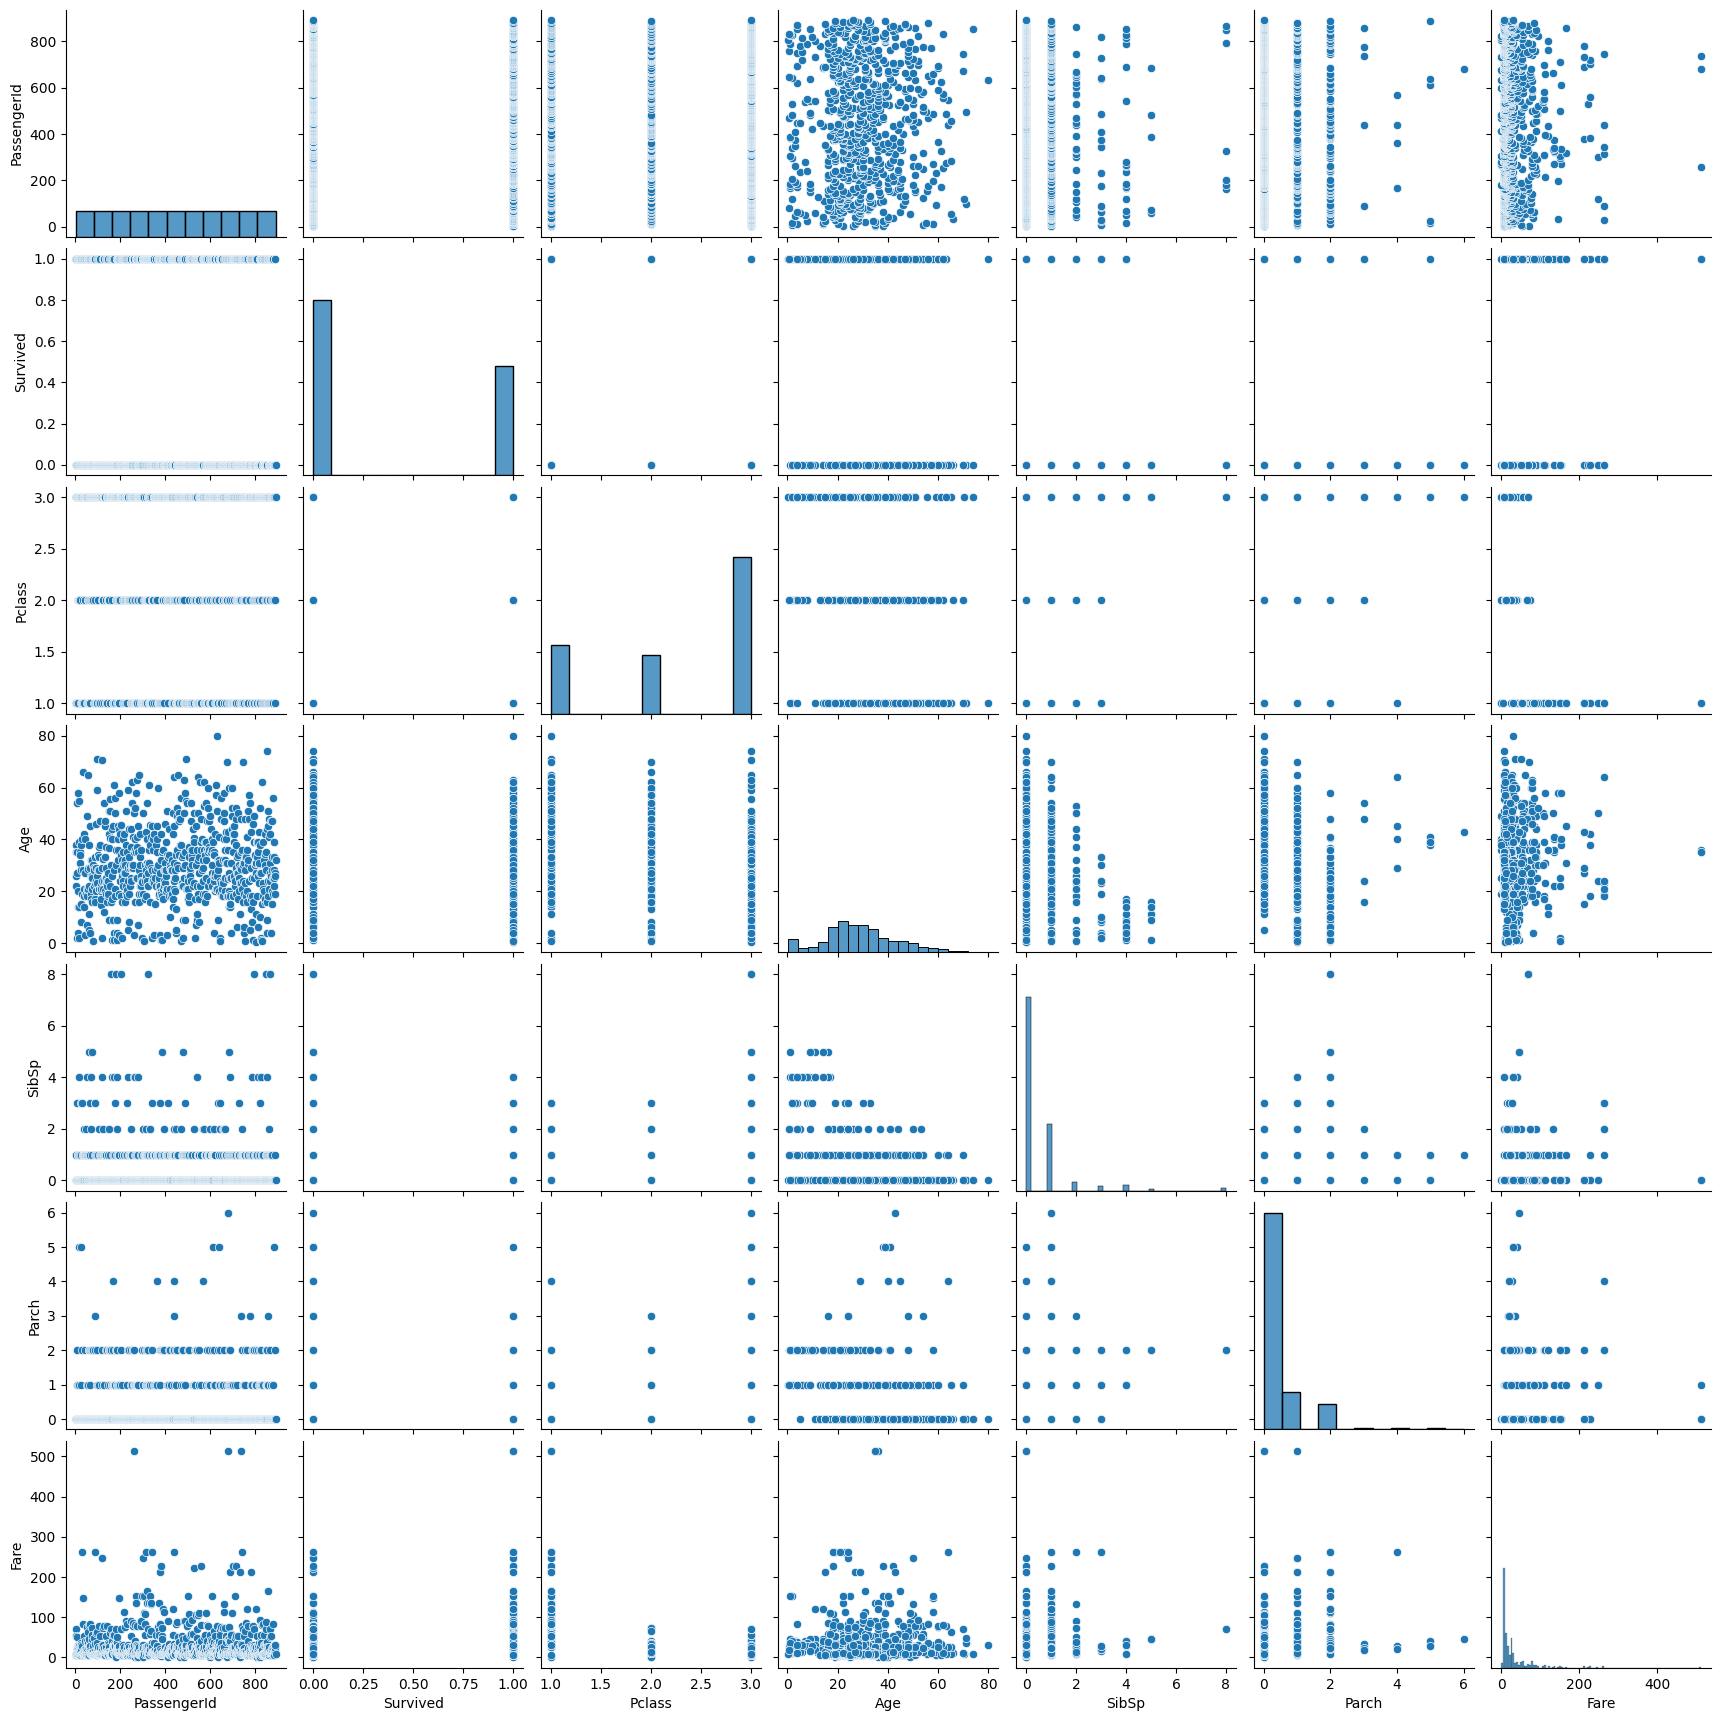

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе

In [16]:
# Group data by Pclass and Sex and count occurrences
sunburst_data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')

# Create the sunburst plot
fig = px.sunburst(sunburst_data, path=['Pclass', 'Sex'], values='count',
                  title='Distribution of Passengers by Pclass and Sex')

# Show the plot
fig.show()